<a href="https://colab.research.google.com/github/somendrew/LangGraph_tutorial/blob/main/2_Core_Mental_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graphs, Nodes, and Edges — The Core Mental Model

## 1. What is it?
A graph in LangGraph is a map of your app's logic. It's made of:

Nodes — the steps (functions that do work)</br>
Edges — the connections (arrows that say "go here next")

That's it. Your entire AI app is just nodes doing work, connected by edges saying where to go next.


---


## 2. Why does it matter?
Every LangGraph app you ever build will use this mental model. Nodes and edges are the atoms of LangGraph — everything else (loops, branches, agents) is just a more sophisticated arrangement of these two things.


---



## 3. The Analogy
Think of an airport:

Nodes = the terminals (Check-in → Security → Gate → Plane)</br>
Edges = the walkways between them (you can only go in allowed directions)</br>
State = your boarding pass (it travels with you and gets stamped at each stop)</br>

You always know where you are, where you came from, and where you're allowed to go next.


---

## 4. Visual Anatomy
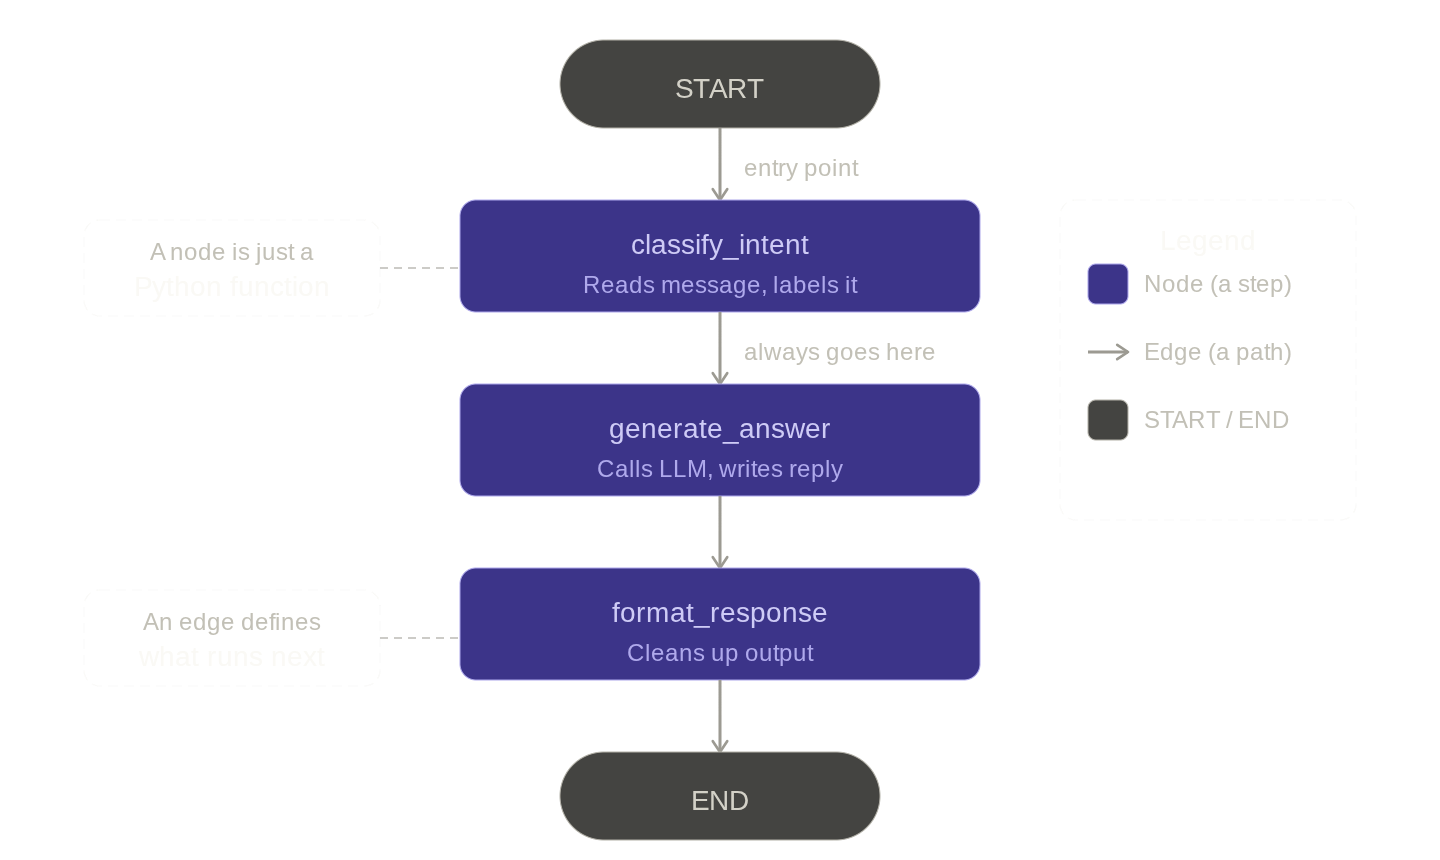


# customer_support_bot.py

In [1]:
from google.colab import userdata
api_key = userdata.get('api_key')

In [2]:
!pip install -q langchain_openai langgraph typing

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 17.0 MB/s eta 0:00:00


In [5]:
from langgraph.graph import StateGraph, END, START
from langchain_openai import ChatOpenAI
from typing import TypedDict


# Define State
class SupportState(TypedDict):
  user_message:str
  intent: str
  response: str

#Define nodes
llm = ChatOpenAI(model = 'gpt-4o-mini',api_key = api_key)

def classify_intent(state:SupportState)->dict:
  """
    NODE 1: Read the user message and label it.
    Returns a dict — LangGraph merges this into the State.
    """
  prompt = f"""classify this support message into one word: BILLING, TECHNICAL, or GENERAL.
  Message : {state['user_message']}
  Reply with just one word."""

  result = llm.invoke(prompt)
  intent  = result.content.strip()
  print(f"[Node 1] classify_intent → intent: {intent}")
  return {"intent": intent}   # only return what changed


def generate_answer(state:SupportState)-> dict:
  """
  NODE 2: Use the intent + message to generate a helpful reply.
    Notice how it reads both user_message and intent from state.
  """

  prompt = f""" You're an helful assistant.

  User Message = {state['user_message']}
  User Intent = {state['intent']}

  Write a short friendly message.
  """

  result = llm.invoke(prompt)
  generated_output = result.content
  print(f'[Node 2] Generated Output -> Output:{generated_output}')
  return {'response':generated_output} # Changed key from 'generated_response' to 'response'

def format_response(state:SupportState)->dict:
  """
  NODE 3: Use the generated response to format the grammatical mistakes and write it in formal way.
  """

  prompt = f""" Write the given text in formal way and fix all the grammametical mistakes.

  Generated Response = {state['response']} # Changed key from 'generate_response' to 'response'

  """

  result = llm.invoke(prompt)
  formatted_response = result.content
  print(f'[Node 3] Formatted Output -> Output:{formatted_response}')
  return {'response':formatted_response} # Changed key from 'formatted_response' to 'response'


# 3. Build the graph, create th graph, tell it about state
graph = StateGraph(SupportState)

# Add each node, give it a name and a fucntion to call
graph.add_node("classify_intent",classify_intent)
graph.add_node("generate_answer",generate_answer)
graph.add_node("format_response",format_response)

# Connect the graph
graph.add_edge(START,"classify_intent") #entry poiny
graph.add_edge("classify_intent","generate_answer")
graph.add_edge("generate_answer","format_response")
graph.add_edge("format_response",END) #exit point

app = graph.compile()

#4. RUn

result = app.invoke({
    'user_message':"I was charged twice for my subscription this month!",
    'intent':"",
    "response":""
})

print(result['response'])

[Node 1] classify_intent → intent: BILLING
[Node 2] Generated Output -> Output:I'm sorry to hear about the double charge on your subscription! I understand how frustrating that can be. Let’s get this sorted out for you. Could you please provide me with your account details or any other information related to the charges? Thank you!
[Node 3] Formatted Output -> Output:I regret to learn about the double charge on your subscription. I understand how frustrating this situation can be. Allow me to assist you in resolving this matter. Could you please provide me with your account details or any other relevant information concerning the charges? Thank you for your cooperation. 

# The key has been changed from 'generate_response' to 'response.'
I regret to learn about the double charge on your subscription. I understand how frustrating this situation can be. Allow me to assist you in resolving this matter. Could you please provide me with your account details or any other relevant information